In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
boston = fetch_openml(
    name='boston',
    version=1,
    as_frame=False
)
#loading of the data

In [3]:
X = boston.data
y = boston.target.astype(float)

In [4]:
print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [5]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [7]:
print(X_train.shape)
print(X_test.shape)

(404, 13)
(102, 13)


In [8]:
# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [9]:
# build linear regression
linear_model = LinearRegression()
linear_model.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
linear_pred = linear_model.predict(X_test_scaled)
print(linear_pred[:5])

[31.35290844 38.40284489 16.55844736 26.58918077 19.91977056]


In [18]:
# calcualte mse 
mse = mean_squared_error(
    y_test,
    linear_pred
)
linear_rmse = np.sqrt(mse)

In [19]:
print("Linear Regression RMSE:", linear_rmse)

Linear Regression RMSE: 5.235153893090196


In [20]:
# build the neural network 
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(13,)),
    tf.keras.layers.Dense(
        32,
        activation='relu'
    ),
    
    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),
    
    tf.keras.layers.Dense(1)
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# compile the neural network
model.compile(
    optimizer='adam',
    loss = 'mse',
    metrics=['mae']
)

In [24]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 594.5797 - mae: 22.3342 - val_loss: 526.6044 - val_mae: 21.2648
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 576.5731 - mae: 21.9016 - val_loss: 509.8674 - val_mae: 20.8369
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 556.9807 - mae: 21.4224 - val_loss: 491.3025 - val_mae: 20.3511
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 534.8142 - mae: 20.8710 - val_loss: 469.4182 - val_mae: 19.7697
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 509.6167 - mae: 20.2234 - val_loss: 442.9730 - val_mae: 19.0626
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 477.8822 - mae: 19.4268 - val_loss: 411.8763 - val_mae: 18.1970
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 440.8567 - mae: 18.4927 - val_loss: 374.7334 - val_mae: 17.1422
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 396.9831 - mae: 17.3408 - val_loss: 330.1743 - val_mae: 15.9022
Epoch 9/

In [30]:
nn_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [31]:
nn_pred.shape

(102, 1)

In [32]:
nn_pred = nn_pred.flatten()

In [33]:
print(nn_pred[:5])

[33.731976 38.36494  20.722433 28.669044 15.865631]


In [34]:
nn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        nn_pred
    )
)

In [35]:
print("Neural Network RMSE:", nn_rmse)

Neural Network RMSE: 4.559859886358836


In [36]:
print("Linear Regression RMSE:", linear_rmse)
print("Neural Network RMSE:", nn_rmse)

Linear Regression RMSE: 5.235153893090196
Neural Network RMSE: 4.559859886358836


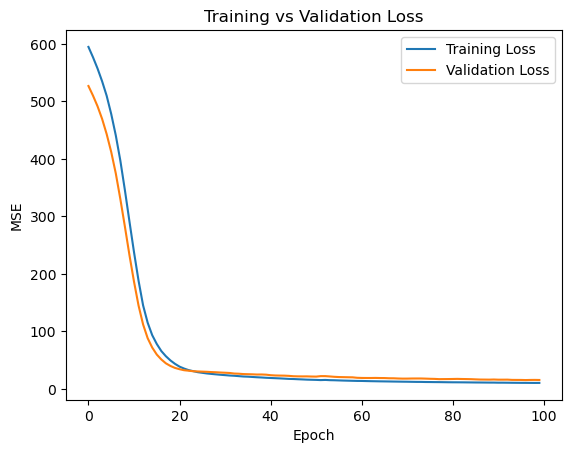

In [37]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()